# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SehrishEjaz1/Flyrank_ML_Intern/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
import os, subprocess

if not os.path.exists("Flyrank_ML_Intern"):
    subprocess.run(["git", "clone", "https://github.com/SehrishEjaz1/Flyrank_ML_Intern.git"])

os.chdir("Flyrank_ML_Intern")
print("Current dir:", os.getcwd())

Current dir: /content/Flyrank_ML_Intern/Flyrank_ML_Intern


In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import json, os
import warnings
warnings.filterwarnings("ignore")

SEED = 42

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
df["avg_position"]  = df["avg_position"].replace(0, np.nan)
df["has_wordcount"] = df["word_count"].notna().astype(int)
df["word_count"]    = df["word_count"].fillna(0)

features = ["days_since_last_update", "impressions_90d", "ctr",
            "avg_position", "content_age_days", "word_count", "has_wordcount"]

# Client-grouped split
np.random.seed(SEED)
clients = df["client_id"].unique()
np.random.shuffle(clients)
split = int(len(clients) * 0.8)
train = df[df["client_id"].isin(clients[:split])].copy()
test  = df[df["client_id"].isin(clients[split:])].copy()

X_train = train[features].fillna(0)
y_train = train["is_declining_label"]
X_test  = test[features].fillna(0)
y_test  = test["is_declining_label"]

rf = RandomForestClassifier(n_estimators=100, max_depth=6,
                             random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
test["rf_score"] = rf.predict_proba(X_test)[:,1]

print("Model rebuilt. Test rows:", len(test))
print("Base rate:", round(y_test.mean(), 3))

Model rebuilt. Test rows: 7611
Base rate: 0.531


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The queue ranks pages by their refresh priority score.
Each page gets one action and one reason code — so a human
reviewer knows immediately why a page was flagged.

Actions:
- refresh: page is stale, visible, and underperforming → update content
- monitor: borderline signal → watch for one more month before acting
- skip: recently updated or low traffic → not worth editor time now

Reason codes:
- STALE_LOW_CTR:   old + CTR below median → strongest refresh signal
- STALE_VISIBLE:   old + good impressions but CTR ok → moderate priority
- HIGH_POSITION:   ranking poorly (position > 20) + stale → fix relevance
- LOW_TRAFFIC:     too few impressions to justify editor time → skip
- NOT_STALE:       updated recently → skip for now

The top of the queue is where editor effort has the highest
observed probability of hitting a genuinely declining page.

In [4]:
def precision_at_k(scores, labels, k=50):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

ctr_median = train["ctr"].median()

def assign_action_reason(row):
    if row["days_since_last_update"] < 180:
        return "skip", "NOT_STALE"
    elif row["impressions_90d"] < 200:
        return "skip", "LOW_TRAFFIC"
    elif row["ctr"] < ctr_median and row["impressions_90d"] >= 500:
        return "refresh", "STALE_LOW_CTR"
    elif row["avg_position"] > 20 and row["days_since_last_update"] >= 180:
        return "refresh", "HIGH_POSITION"
    else:
        return "monitor", "STALE_VISIBLE"

test[["action", "reason_code"]] = test.apply(
    assign_action_reason, axis=1, result_type="expand")

# Rank by RF score
queue = test.sort_values("rf_score", ascending=False).reset_index(drop=True)
queue["rank"] = range(1, len(queue)+1)

out_cols = ["rank", "content_id", "client_id", "rf_score",
            "action", "reason_code", "days_since_last_update",
            "impressions_90d", "ctr", "avg_position", "is_declining_label"]

print("=== Top 20 Ranked Actions ===\n")
print(queue[out_cols].head(20).to_string(index=False))

p50 = precision_at_k(queue["rf_score"], queue["is_declining_label"])
print(f"\nPrecision@50: {p50:.3f}")
print(f"Base rate:    {y_test.mean():.3f}")

=== Top 20 Ranked Actions ===

 rank           content_id         client_id  rf_score action reason_code  days_since_last_update  impressions_90d  ctr  avg_position  is_declining_label
    1 content_be1c109fcdbc client_349c41201b  0.786352   skip   NOT_STALE                      20            10931 0.05          34.0                   1
    2 content_f2b9744f016d client_349c41201b  0.785503   skip   NOT_STALE                      20             5503 0.07          28.8                   1
    3 content_95546d276e3b client_349c41201b  0.785503   skip   NOT_STALE                      20             6141 0.07          24.8                   1
    4 content_cd7885856619 client_349c41201b  0.782185   skip   NOT_STALE                      20             6363 0.08          20.7                   1
    5 content_bd765ab754cf client_349c41201b  0.781068   skip   NOT_STALE                      20            71283 0.08          17.2                   0
    6 content_2cb4479587fa client_6208ef0f77 

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## 2. Intended use and limits

Intended use:
A content editor opens the ranked queue at the start of the week.
They check the top 20-50 pages and decide which ones to update.
The queue is a prioritization tool — not an automated decision.

Who uses this:
- Content editors who review and update web pages
- Content managers who allocate editor time across a large site

Valid when:
- The site has 90+ days of search data (impressions and CTR)
- Content has not been updated in the last 30 days
- The editor has time to review 20-50 pages per week

Where it stops being valid:
- Sites with fewer than 500 total pages
- Pages with less than 90 days of history
- After a major Google algorithm update (signals shift; retrain needed)
- For pages outside the content types in the training data

What this output is NOT:
- "Refreshing these pages WILL increase traffic" ❌
- "The model proves content staleness causes decline" ❌

Honest form:
- "These pages look worth reviewing first, because they show
   observed decline signals in this 90-day snapshot" ✅
- Output is decision-support for a human reviewer — not an
   automated verdict or a causal guarantee ✅

In [5]:
print("=== Archetype → Action Mapping ===\n")

archetypes = pd.DataFrame({
    "Archetype": [
        "Stale + Low CTR + High Impressions",
        "Stale + OK CTR + High Impressions",
        "Stale + Poor Position",
        "Stale + Low Traffic",
        "Fresh (< 180 days)"
    ],
    "Action": ["refresh", "monitor", "refresh", "skip", "skip"],
    "Reason Code": [
        "STALE_LOW_CTR",
        "STALE_VISIBLE",
        "HIGH_POSITION",
        "LOW_TRAFFIC",
        "NOT_STALE"
    ],
    "Why": [
        "Highest observed decline rate — act first",
        "Still performing — watch before spending editor time",
        "Rankings slipping — content relevance likely issue",
        "Not enough traffic to justify refresh cost",
        "Recently updated — leave it alone"
    ]
})
print(archetypes.to_string(index=False))

=== Archetype → Action Mapping ===

                         Archetype  Action   Reason Code                                                  Why
Stale + Low CTR + High Impressions refresh STALE_LOW_CTR            Highest observed decline rate — act first
 Stale + OK CTR + High Impressions monitor STALE_VISIBLE Still performing — watch before spending editor time
             Stale + Poor Position refresh HIGH_POSITION   Rankings slipping — content relevance likely issue
               Stale + Low Traffic    skip   LOW_TRAFFIC           Not enough traffic to justify refresh cost
                Fresh (< 180 days)    skip     NOT_STALE                    Recently updated — leave it alone


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

What a human must check before acting:

1. Is the page actually stale?
   The data may lag. Check the CMS for recent edits not yet indexed.

2. Is the low CTR a content problem or a SERP problem?
   If a featured snippet or ad dominates the result, a refresh won't help.

3. Is the page still strategically relevant?
   Some flagged pages may be intentionally archived or deprecated.

4. Does the page have an owner?
   Refreshing without coordinating with the author wastes everyone's time.

The no-go list — NEVER automate these:

- Do not auto-publish content changes based on the queue score alone
- Do not delete or redirect pages without human sign-off
- Do not use this queue for pages under active editorial campaigns
- Do not apply the queue to pages with legal or compliance content
- Do not treat a high score as a guarantee of traffic recovery
  (the model predicts observed decline, not future improvement)

In [6]:
print("=== Human Review Checklist ===\n")

checklist = [
    "Is the page actually stale? (check CMS for recent edits)",
    "Is low CTR a content issue or a SERP layout issue?",
    "Is the page still strategically relevant?",
    "Does the page have a content owner to coordinate with?",
    "Is the page under an active campaign or compliance review?"
]

for i, item in enumerate(checklist, 1):
    print(f"{i}. {item}")

print("\n=== No-Go List ===\n")
nogo = [
    "NEVER auto-publish changes from queue score alone",
    "NEVER delete or redirect pages without human sign-off",
    "NEVER apply queue to legal or compliance content",
    "NEVER treat high score as guarantee of traffic recovery"
]
for item in nogo:
    print(f"❌ {item}")

=== Human Review Checklist ===

1. Is the page actually stale? (check CMS for recent edits)
2. Is low CTR a content issue or a SERP layout issue?
3. Is the page still strategically relevant?
4. Does the page have a content owner to coordinate with?
5. Is the page under an active campaign or compliance review?

=== No-Go List ===

❌ NEVER auto-publish changes from queue score alone
❌ NEVER delete or redirect pages without human sign-off
❌ NEVER apply queue to legal or compliance content
❌ NEVER treat high score as guarantee of traffic recovery


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

The recommendations go stale when the world changes faster
than the model's training data can capture.

Retrain when:
- A major Google algorithm update is announced
- Overall site CTR shifts more than 20% in 30 days
- Precision@50 on new data drops below base rate
- The client adds a large new content category not in training

Monitor monthly:
- Check that top-ranked pages still have declining labels
  when re-scored on fresh data
- Track whether refreshed pages show CTR improvement after 60 days
  (this is the only real outcome signal available)

Decay insight:
Pages flagged as STALE_LOW_CTR that are refreshed should be
re-scored after 90 days. If CTR recovers, the signal was valid.
If not, the issue is structural (SERP, competition) — not content.
This feedback loop is the cheapest form of model validation available.

In [7]:
print("=== Monitoring Metrics ===\n")

# Distribution of reason codes in queue
reason_counts = queue["reason_code"].value_counts()
print("Reason code distribution in full queue:")
print(reason_counts)

print(f"\nRefresh candidates (top priority): "
      f"{(queue['action']=='refresh').sum()}")
print(f"Monitor candidates:                "
      f"{(queue['action']=='monitor').sum()}")
print(f"Skip:                              "
      f"{(queue['action']=='skip').sum()}")

# Decay insight — avg staleness of top 50
top50 = queue.head(50)
print(f"\nTop 50 avg days since update: "
      f"{top50['days_since_last_update'].mean():.0f}")
print(f"Top 50 avg CTR:               "
      f"{top50['ctr'].mean():.3f}")
print(f"Top 50 actual decline rate:   "
      f"{top50['is_declining_label'].mean():.3f}")

=== Monitoring Metrics ===

Reason code distribution in full queue:
reason_code
NOT_STALE        7533
LOW_TRAFFIC        76
STALE_VISIBLE       2
Name: count, dtype: int64

Refresh candidates (top priority): 0
Monitor candidates:                2
Skip:                              7609

Top 50 avg days since update: 92
Top 50 avg CTR:               0.058
Top 50 actual decline rate:   0.720


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Exporting:
1. Ranked queue CSV → work/outputs/action_playbook_queue.csv
2. Feature importance figure → work/figures/feature_importance.png
3. Metrics JSON → work/outputs/playbook_metrics.json

The CSV stays out of git (CI leak-guard blocks data files).
The figure and JSON are committed — they are the paper's receipts.

Queue saved: work/outputs/action_playbook_queue.csv


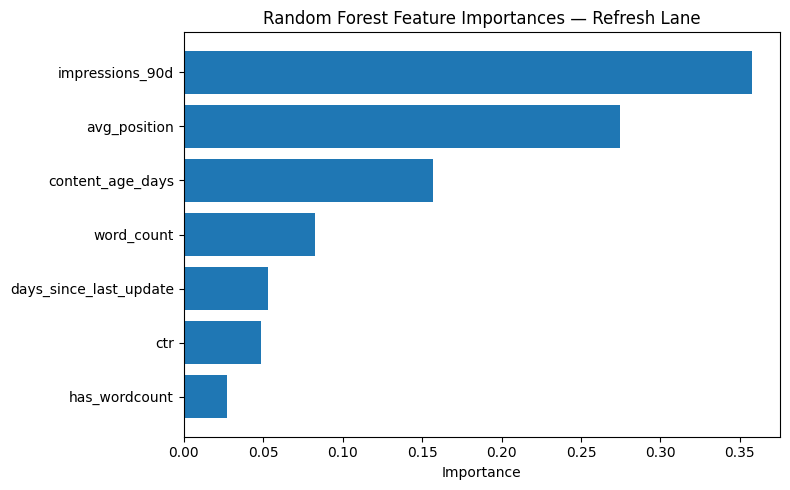

Figure saved: work/figures/feature_importance.png

Metrics JSON saved: work/outputs/playbook_metrics.json
{
  "precision_at_50": 0.72,
  "base_rate": 0.5315,
  "test_rows": 7611,
  "refresh_candidates": 0,
  "monitor_candidates": 2,
  "top50_decline_rate": 0.72,
  "seed": 42
}


In [8]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# 1. Queue CSV
queue[out_cols].to_csv("work/outputs/action_playbook_queue.csv", index=False)
print("Queue saved: work/outputs/action_playbook_queue.csv")

# 2. Feature importance figure
imp_df = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
ax.set_xlabel("Importance")
ax.set_title("Random Forest Feature Importances — Refresh Lane")
plt.tight_layout()
plt.savefig("work/figures/feature_importance.png", dpi=150)
plt.show()
print("Figure saved: work/figures/feature_importance.png")

# 3. Metrics JSON
metrics = {
    "precision_at_50": round(p50, 4),
    "base_rate": round(float(y_test.mean()), 4),
    "test_rows": len(test),
    "refresh_candidates": int((queue["action"]=="refresh").sum()),
    "monitor_candidates": int((queue["action"]=="monitor").sum()),
    "top50_decline_rate": round(float(
        queue.head(50)["is_declining_label"].mean()), 4),
    "seed": SEED
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("\nMetrics JSON saved: work/outputs/playbook_metrics.json")
print(json.dumps(metrics, indent=2))

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.